<a href="https://colab.research.google.com/github/TWecks/Quantum-Error-Correction/blob/main/02_phase_flip_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=386955f9bf625d2e7c3b1489b5613b0ae251670494f672438b2da76a5afbc9d2
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
from qiskit import QuantumCircuit,transpile
from qiskit.visualization import plot_histogram
import qiskit_aer
from qiskit_aer import AerSimulator
from qiskit import ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter


import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


In [4]:
# Prepare a perfect simulator
backend_sim_perfect = AerSimulator()

# Prepare a noisy simulator
from qiskit_aer.noise import NoiseModel,depolarizing_error,ReadoutError
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ['cx', 'cz'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(4e-3, 1), ['id', 'z', 's', 'sdg', 't', 'tdg', 'x', 'rx', 'y', 'ry'])
noise_model.add_all_qubit_readout_error(ReadoutError([[0.98,0.02],[0.02,0.98]]))
backend_sim_noisy = AerSimulator(noise_model=noise_model)

# Correcting a Phase Flip Error

In order to detect and correct Z errors, it will be necessary to use a hadamard rotated code

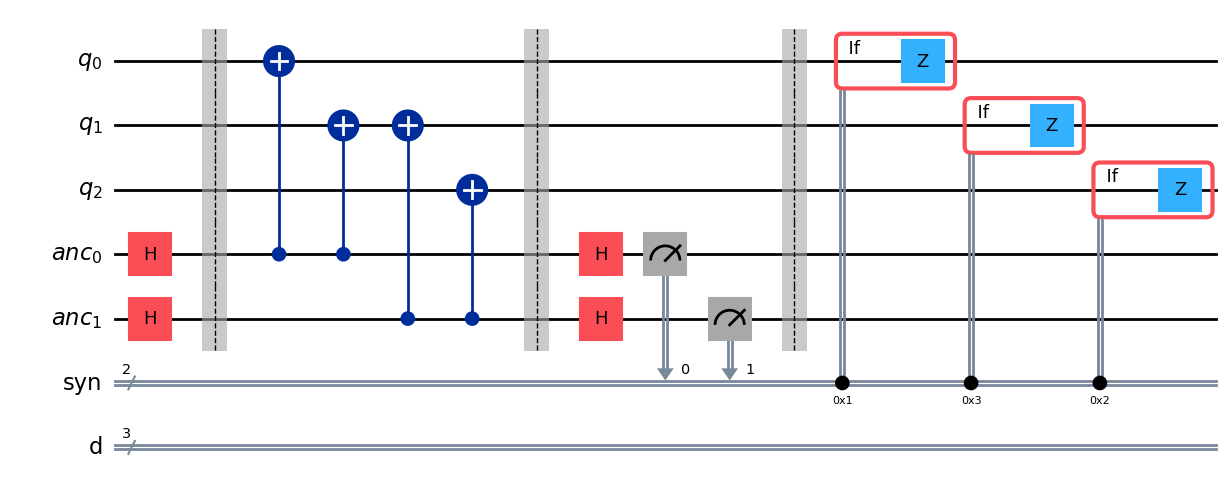

In [8]:
qr = QuantumRegister(3, 'q')
anc = QuantumRegister(2, 'anc')
syndrome = ClassicalRegister(2, 'syn')
readout = ClassicalRegister(3, 'd')

z_corrected = QuantumCircuit(qr, anc, syndrome, readout)



# prepare ancilla in |+> state
z_corrected.h([anc[0], anc[1]])

z_corrected.barrier()

# syndrome extraction via phase kickback
z_corrected.cx(anc[0], qr[0])
z_corrected.cx(anc[0], qr[1])
z_corrected.cx(anc[1], qr[1])
z_corrected.cx(anc[1], qr[2])

z_corrected.barrier()

# rotate ancilla back to Z basis and measure
z_corrected.h([anc[0], anc[1]])
z_corrected.measure(anc[0], syndrome[0])
z_corrected.measure(anc[1], syndrome[1])

z_corrected.barrier()

# correction
with z_corrected.if_test((syndrome, 0b01)):
    z_corrected.z(qr[0])

with z_corrected.if_test((syndrome, 0b11)):
    z_corrected.z(qr[1])

with z_corrected.if_test((syndrome, 0b10)):
    z_corrected.z(qr[2])

z_corrected.draw('mpl')

Just like in the previous notebook, we can introduce an intentional error and graph the result with and without correction. In this case, we will skip straight to introducing an Rz($\phi$) type error for $0 \leq \phi \leq 2\pi$. Also like before, we will initialize to a GHZ state.

In [38]:
phi = Parameter('φ')

arb_z_rot = QuantumCircuit(qr, anc, syndrome, readout)




#encode
arb_z_rot.cx(0, 1)
arb_z_rot.cx(0, 2)
arb_z_rot.h([0,1,2])

# induce  Z error
arb_z_rot.barrier()
arb_z_rot.rz(phi, 1)
arb_z_rot.barrier()

# correct Z error
arb_z_rot.compose(z_corrected, inplace=True)

arb_z_rot.barrier()

# decode
arb_z_rot.h([0,1,2])

arb_z_rot.cx(0, 2)
arb_z_rot.cx(0, 1)

arb_z_rot.barrier()

# readout
arb_z_rot.measure(0, readout[0])
arb_z_rot.measure(1, readout[1])
arb_z_rot.measure(2, readout[2])


arb_z_nocorrection = QuantumCircuit(qr, anc, syndrome, readout)

arb_z_nocorrection.h(0)
arb_z_nocorrection.cx(0, 1)
arb_z_nocorrection.cx(0, 2)
arb_z_nocorrection.barrier()
arb_z_nocorrection.rz(phi, 1)
arb_z_nocorrection.barrier()
arb_z_nocorrection.measure(0, readout[0])
arb_z_nocorrection.measure(1, readout[1])
arb_z_nocorrection.measure(2, readout[2])

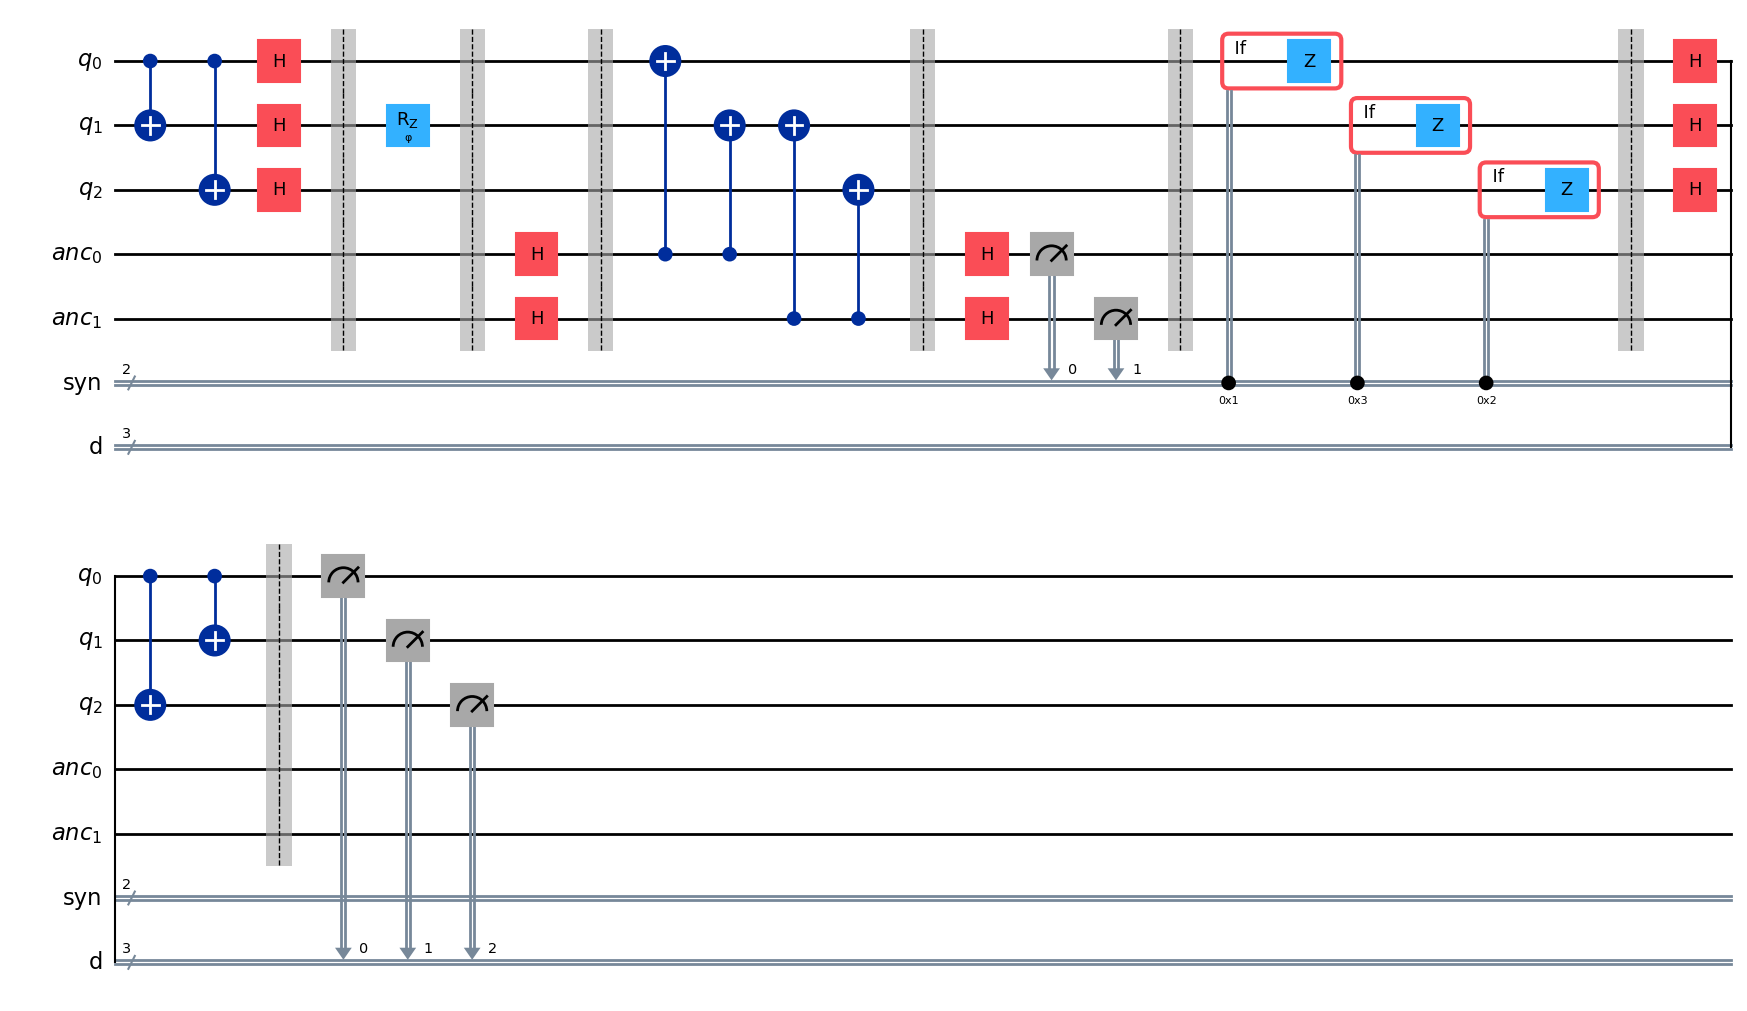

In [42]:
arb_z_rot.draw('mpl')

In [39]:
# Sweep phi from 0 to 2pi
phi_values = np.linspace(0, 2*np.pi, 50)

# Run a job for each phi value
counts_per_phi = []
for t in phi_values:
    bound_circZ = arb_z_rot.assign_parameters({phi: t})
    circ_compZ = transpile(bound_circZ, backend_sim_perfect)
    job = backend_sim_perfect.run(circ_compZ, shots=1024)
    result = job.result()
    raw = result.get_counts()
    # extract data_out register
    filtered = {}
    for bitstring, count in raw.items():
        key = bitstring.split()[0]
        filtered[key] = filtered.get(key, 0) + count
    counts_per_phi.append(filtered)

# Extract probability of |000> and |111> across theta sweep
all_states = ['000', '111', '001', '010', '100', '011', '101', '110']
prob_by_state = {s: [] for s in all_states}

for counts in counts_per_phi:
    total = sum(counts.values())
    for s in all_states:
        prob_by_state[s].append(counts.get(s, 0) / total)


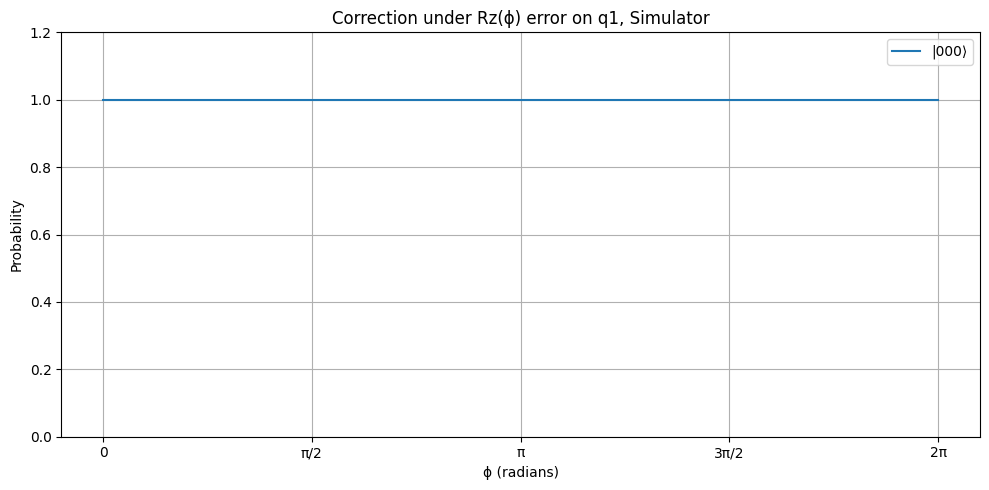

In [41]:
# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for s in all_states:
    if max(prob_by_state[s]) > 0.01:  # only plot states that appear
        plt.plot(phi_values, prob_by_state[s], label=f'|{s}⟩')

plt.xlabel('ϕ (radians)')
plt.ylabel('Probability')
plt.title('Correction under Rz(ϕ) error on q1, Simulator')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.legend()
plt.ylim(0, 1.2)

plt.grid(True)
plt.tight_layout()
plt.show()

Great,  for each value of theta we get the initial state $|000>$ with probability one, thus demonstrating our code is working. In the next notebook we put it all together, and present a code to correct both X and Z errors.